<a href="https://colab.research.google.com/github/2025ag05585-hue/Python-programming-Basic/blob/main/AutoEncoder_BITS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from keras.models import Model

In [ ]:
# Get The Data
(x_train , _) , (x_test , _ ) = mnist.load_data()

# Reshape The Data
x_train = x_train.reshape(x_train.shape[0] , x_train.shape[1] , x_train.shape[2] , 1)
x_test = x_test.reshape(x_test.shape[0] , x_test.shape[1] , x_test.shape[2] , 1)

# Standarize The Data
x_train = x_train / 255
x_test  = x_test / 255



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Function to display The Data

def display_data(data , height, width, title):
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(data[i].reshape((height,width)))
        plt.gray()
    plt.suptitle(title)



In [ ]:
# Our Convolution AutoEncoder
def Conv_AutoEncoder() :
    #Input Layer
    input_layer = Input(shape=(28, 28, 1), name="input_layer")
    # Encoder
    x = Conv2D(16, (3, 3), activation='relu')(input_layer)
    x = MaxPooling2D((2, 2) , strides=(2,2))(x)
    x = Conv2D(8, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2) , strides=(2,2) , name = 'code_layer')(x)
    # Code
    code = x
    # Decoder
    x = UpSampling2D((2, 2))(code)
    x = Conv2DTranspose(8, (3, 3), activation='relu')(x)
    x = UpSampling2D((2, 2) )(x)
    x = Conv2DTranspose(16, (3, 3), activation='relu')(x)
    # Output Layer
    output_layer = Conv2DTranspose(1, (3, 3), activation='sigmoid')(x)

    conv_Autoencoder = Model(input_layer , output_layer)

    return conv_Autoencoder



In [ ]:
# Compiling The Model

Convolution_AutoEncoder = Conv_AutoEncoder()
Convolution_AutoEncoder.compile(optimizer='adam', loss='mse')
Convolution_AutoEncoder.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ code_layer (MaxPooling2D)       │ (None, 5, 5, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 12, 12, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 26, 26, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training The Model
Convolution_AutoEncoder.fit(x_train , x_train , epochs=2 , batch_size=32 , shuffle=True , validation_data=(x_test , x_test))


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.0162 - val_loss: 0.0069
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0063 - val_loss: 0.0056


In [ ]:

# get The Decoded Data
decoded_data = Convolution_AutoEncoder.predict(x_test)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


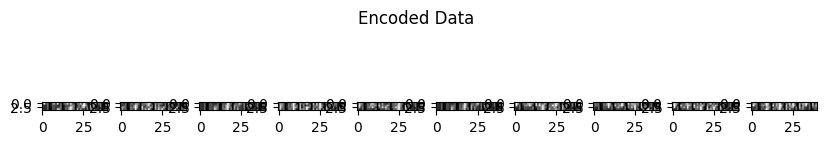

In [ ]:
Encoder = Model(inputs = Convolution_AutoEncoder.input , outputs = Convolution_AutoEncoder.get_layer("code_layer").output)

# get The Encoded Data
encoded_data = Encoder.predict(x_test)

# display The Result


display_data(encoded_data , height = 5 , width = 5*8 , title = 'Encoded Data')


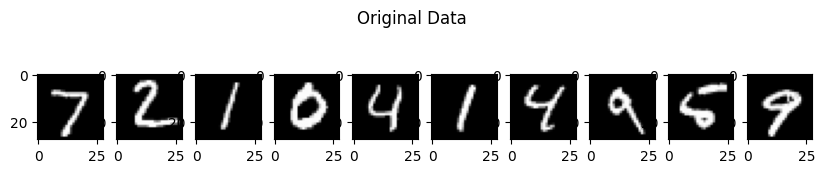

In [ ]:
display_data(x_test , height = 28 , width = 28 , title = 'Original Data')

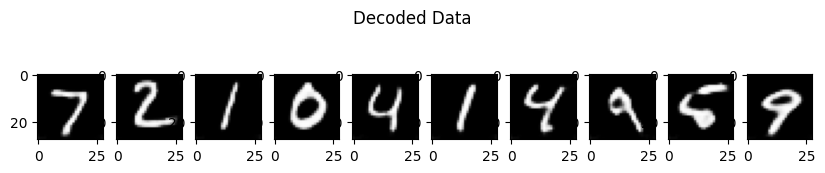

In [ ]:
display_data(decoded_data , height = 28 , width = 28 , title = 'Decoded Data')